# Жесткая задача: уравнение Бонгоффера--Ван-дер-Поля

Рассматривается система

$$
\begin{cases}
y_1' = a \left( -\left( \frac{y_1^3}{3} - y_1 \right) + y_2 \right), \\
y_2' = -y_1 - by_2 + c,\\
y_1(0)=2,\quad y_2(0)=0,
\end{cases}
$$

на отрезке $0\le t\le T_k$, где $T_k=20$. В расчетах используются два значения жесткого параметра: $a=10^3$ и $a=10^6$.

Так как в условии для $b$ и $c$ заданы только ограничения $b>0$, $0<c<1$, выбраны параметры

$$
b=0.8,\qquad c=0.7.
$$

Они удовлетворяют ограничениям и дают характерный режим релаксационных колебаний.

## Постановка задачи

### Краткое описание физической модели

Модель Бонгоффера--Ван-дер-Поля является одной из форм уравнений ФитцХью--Нагумо. Она описывает прохождение тока через клеточную мембрану и качественно воспроизводит возбуждение и восстановление мембранного потенциала. Переменная $y_1$ играет роль быстрой переменной, а $y_2$ -- медленной восстановительной переменной.

### Краткое описание математической модели

Система имеет вид

$$
y' = f(t,y), \qquad y=(y_1,y_2)^T.
$$

Правая часть автономна и нелинейна. Матрица Якоби:

$$
J(y)=
\begin{pmatrix}
a(1-y_1^2) & a\\
-1 & -b
\end{pmatrix}.
$$

При больших $a$ в системе появляется быстрое направление. На начальном участке при $y_1(0)=2$ оценка быстрой собственной компоненты имеет порядок $-3a$, поэтому для явных методов устойчивый шаг должен быть порядка $1/a$.

### Свойства ожидаемого решения

Решение является релаксационным: большую часть времени оно медленно движется вдоль ветвей медленного многообразия

$$
y_2 \approx \frac{y_1^3}{3}-y_1,
$$

а затем быстро перескакивает на другую ветвь. Чем больше $a$, тем уже быстрые переходные слои и тем жестче численная задача.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

B = 0.8
C = 0.7
Y0 = np.array([2.0, 0.0])
T0, T_END = 0.0, 20.0


def f_bvp(t, y, a, b=B, c=C):
    y1, y2 = y
    return np.array([
        a * (-(y1**3 / 3.0 - y1) + y2),
        -y1 - b * y2 + c,
    ], dtype=float)


def jac_bvp(t, y, a, b=B, c=C):
    y1, y2 = y
    return np.array([
        [a * (1.0 - y1**2), a],
        [-1.0, -b],
    ], dtype=float)


def finite_prefix(t, y):
    mask = np.all(np.isfinite(y), axis=1)
    if mask.all():
        return t, y
    first_bad = int(np.argmax(~mask))
    return t[:first_bad], y[:first_bad]

## Внутренние решатели из работ прошлого семестра

В условии отдельно требуется использовать модули решения СЛАУ и СНУ из предыдущих лабораторных. В каталоге `sem1` они сохранены как notebooks, а не как импортируемые `.py`-модули:

- `sem1/SLAE/solve_slae.ipynb`;
- `sem1/non-linear/non_linear.ipynb`.

Ниже интегрированы нужные блоки: LU-разложение с частичным выбором главного элемента для СЛАУ и метод Ньютона для систем нелинейных уравнений. Они используются в неявных методах, BDF2 и Rosenbrock-схеме.

In [2]:
def lu_decomposition_pp(A):
    A = np.array(A, dtype=float, copy=True)
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n, dtype=float)
    P = np.arange(n)

    for k in range(n - 1):
        pivot = k + np.argmax(np.abs(U[k:, k]))
        if abs(U[pivot, k]) < 1e-15:
            raise np.linalg.LinAlgError("Singular matrix during LU decomposition.")

        if pivot != k:
            U[[k, pivot]] = U[[pivot, k]]
            P[[k, pivot]] = P[[pivot, k]]
            if k > 0:
                L[[k, pivot], :k] = L[[pivot, k], :k]

        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
            U[i, k] = 0.0

    return P, L, U


def lu_solve(A, b):
    P, L, U = lu_decomposition_pp(A)
    b = np.asarray(b, dtype=float)[P]
    n = L.shape[0]

    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - L[i, :i] @ y[:i]

    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        if abs(U[i, i]) < 1e-15:
            raise np.linalg.LinAlgError("Singular matrix in back substitution.")
        x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x


def newton_system(F, J, x0, tol=1e-10, max_iter=20):
    x = np.asarray(x0, dtype=float).copy()
    for k in range(max_iter):
        Fx = np.asarray(F(x), dtype=float)
        if np.linalg.norm(Fx, ord=2) <= tol:
            return x, k, np.linalg.norm(Fx, ord=2)
        dx = lu_solve(J(x), -Fx)
        x = x + dx
        if np.linalg.norm(dx, ord=2) <= tol * (1.0 + np.linalg.norm(x, ord=2)):
            return x, k + 1, np.linalg.norm(np.asarray(F(x), dtype=float), ord=2)
    return x, max_iter, np.linalg.norm(np.asarray(F(x), dtype=float), ord=2)

## Методы численного решения

### Явные методы для проверки устойчивости

Для сравнения используются явный Эйлер и классический RK4. Они не являются подходящими основными методами для жесткой задачи, но хорошо показывают ограничение по устойчивости.

Для тестового уравнения $u'=\lambda u$ явный метод устойчив только при $h\lambda$ внутри области устойчивости. В нашей системе быстрая компонента имеет масштаб $|\lambda|\sim a$, поэтому при $a=10^6$ явному методу нужен шаг порядка $10^{-6}$ или меньше. На интервале $[0,20]$ это уже десятки миллионов шагов.

### Неявный метод Рунге--Кутты

Выбран двухстадийный Radau IIA порядка 3:

$$
A=\begin{pmatrix}5/12&-1/12\\3/4&1/4\end{pmatrix},
\quad
b=\begin{pmatrix}3/4\\1/4\end{pmatrix},
\quad
c=\begin{pmatrix}1/3\\1\end{pmatrix}.
$$

Метод A-устойчив и L-устойчив, поэтому подходит для жестких задач.

### Метод Розенброка

Используется метод Rosenbrock-типа второго порядка: один шаг Rosenbrock-Euler

$$
y_{n+1}=y_n+(I-hJ_n)^{-1}h f(t_n,y_n)
$$

повышается до второго порядка удвоением шага и экстраполяцией Ричардсона:

$$
y_{n+1}^{(2)}=2y_{h/2,h/2}-y_h.
$$

На каждом шаге решаются только СЛАУ с матрицами вида $I-hJ$, что дешевле полной нелинейной итерации.

### Метод Гира

В качестве метода Гира используется BDF2:

$$
\frac{3y_{n+1}-4y_n+y_{n-1}}{2h}=f(t_{n+1},y_{n+1}).
$$

Первый шаг выполняется неявным методом Эйлера. Для каждого последующего шага применяется метод Ньютона.

In [3]:
def explicit_euler(a, h, t_end=T_END):
    n = int(round((t_end - T0) / h))
    t = np.linspace(T0, t_end, n + 1)
    y = np.empty((n + 1, 2))
    y[0] = Y0
    for i in range(n):
        y[i + 1] = y[i] + h * f_bvp(t[i], y[i], a)
        if not np.all(np.isfinite(y[i + 1])) or np.max(np.abs(y[i + 1])) > 1e8:
            y[i + 1:] = np.nan
            break
    return t, y


def rk4_explicit(a, h, t_end=T_END):
    n = int(round((t_end - T0) / h))
    t = np.linspace(T0, t_end, n + 1)
    y = np.empty((n + 1, 2))
    y[0] = Y0
    for i in range(n):
        ti, yi = t[i], y[i]
        k1 = f_bvp(ti, yi, a)
        k2 = f_bvp(ti + h / 2, yi + h * k1 / 2, a)
        k3 = f_bvp(ti + h / 2, yi + h * k2 / 2, a)
        k4 = f_bvp(ti + h, yi + h * k3, a)
        y[i + 1] = yi + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6
        if not np.all(np.isfinite(y[i + 1])) or np.max(np.abs(y[i + 1])) > 1e8:
            y[i + 1:] = np.nan
            break
    return t, y


def radau_iia3(a, h, t_end=T_END):
    A = np.array([[5/12, -1/12], [3/4, 1/4]], dtype=float)
    weights = np.array([3/4, 1/4], dtype=float)
    nodes = np.array([1/3, 1.0], dtype=float)

    n = int(round((t_end - T0) / h))
    t = np.linspace(T0, t_end, n + 1)
    y = np.empty((n + 1, 2))
    y[0] = Y0
    newton_iters = []

    for m in range(n):
        tm, ym = t[m], y[m]
        Y0_stage = np.tile(ym, 2)

        def G(Y_flat):
            Y = Y_flat.reshape(2, 2)
            out = np.zeros((2, 2))
            for i in range(2):
                rhs = ym + h * sum(
                    A[i, j] * f_bvp(tm + nodes[j] * h, Y[j], a)
                    for j in range(2)
                )
                out[i] = Y[i] - rhs
            return out.reshape(4)

        def JG(Y_flat):
            Y = Y_flat.reshape(2, 2)
            M = np.eye(4)
            for j in range(2):
                Jj = jac_bvp(tm + nodes[j] * h, Y[j], a)
                for i in range(2):
                    M[2*i:2*i+2, 2*j:2*j+2] -= h * A[i, j] * Jj
            return M

        Y_flat, iters, res = newton_system(G, JG, Y0_stage, tol=1e-9, max_iter=15)
        Y = Y_flat.reshape(2, 2)
        y[m + 1] = ym + h * sum(
            weights[j] * f_bvp(tm + nodes[j] * h, Y[j], a)
            for j in range(2)
        )
        newton_iters.append(iters)
        if not np.all(np.isfinite(y[m + 1])) or np.max(np.abs(y[m + 1])) > 1e8:
            y[m + 1:] = np.nan
            break
    return t, y, np.array(newton_iters)


def rosenbrock_euler_step(a, t, y, h):
    J = jac_bvp(t, y, a)
    M = np.eye(2) - h * J
    return y + lu_solve(M, h * f_bvp(t, y, a))


def rosenbrock2(a, h, t_end=T_END):
    n = int(round((t_end - T0) / h))
    t = np.linspace(T0, t_end, n + 1)
    y = np.empty((n + 1, 2))
    y[0] = Y0

    for m in range(n):
        tm, ym = t[m], y[m]
        y_full = rosenbrock_euler_step(a, tm, ym, h)
        y_half = rosenbrock_euler_step(a, tm, ym, h / 2.0)
        y_half2 = rosenbrock_euler_step(a, tm + h / 2.0, y_half, h / 2.0)
        y[m + 1] = 2.0 * y_half2 - y_full
        if not np.all(np.isfinite(y[m + 1])) or np.max(np.abs(y[m + 1])) > 1e8:
            y[m + 1:] = np.nan
            break
    return t, y


def backward_euler_step(a, t_next, y_prev, h):
    def G(z):
        return z - y_prev - h * f_bvp(t_next, z, a)
    def JG(z):
        return np.eye(2) - h * jac_bvp(t_next, z, a)
    z, iters, res = newton_system(G, JG, y_prev, tol=1e-10, max_iter=20)
    return z, iters


def gear_bdf2(a, h, t_end=T_END):
    n = int(round((t_end - T0) / h))
    t = np.linspace(T0, t_end, n + 1)
    y = np.empty((n + 1, 2))
    y[0] = Y0
    newton_iters = []

    y[1], it = backward_euler_step(a, t[1], y[0], h)
    newton_iters.append(it)

    for m in range(1, n):
        ym, ym1 = y[m], y[m - 1]

        def G(z):
            return 3.0 * z - 4.0 * ym + ym1 - 2.0 * h * f_bvp(t[m + 1], z, a)
        def JG(z):
            return 3.0 * np.eye(2) - 2.0 * h * jac_bvp(t[m + 1], z, a)

        predictor = ym + (ym - ym1)
        y[m + 1], iters, res = newton_system(G, JG, predictor, tol=1e-10, max_iter=20)
        newton_iters.append(iters)
        if not np.all(np.isfinite(y[m + 1])) or np.max(np.abs(y[m + 1])) > 1e8:
            y[m + 1:] = np.nan
            break
    return t, y, np.array(newton_iters)

## Референсное решение

Для сравнения используется `solve_ivp` с методом `Radau` и жесткими допусками. Это не является частью требуемой реализации методов, а служит независимым ориентиром для графиков и ошибок.

In [4]:
refs = {}
for a in [1e3, 1e6]:
    sol = solve_ivp(
        lambda t, y, aa=a: f_bvp(t, y, aa),
        (T0, T_END),
        Y0,
        method="Radau",
        jac=lambda t, y, aa=a: jac_bvp(t, y, aa),
        rtol=1e-9,
        atol=1e-11,
        dense_output=True,
    )
    refs[a] = sol
    print(f"a={a:.0e}: success={sol.success}, internal steps={len(sol.t)}, y(20)={sol.y[:, -1]}")

a=1e+03: success=True, internal steps=356, y(20)=[ 1.19940804 -0.62426004]
a=1e+06: success=True, internal steps=362, y(20)=[ 1.19940804 -0.62426004]


## Что происходит с явными методами

Проверим явный Эйлер и RK4 на $a=10^3$. Для $a=10^6$ оценка допустимого шага становится порядка $10^{-6}$, поэтому полноценный расчет до $T=20$ явным методом требует слишком большого числа шагов.

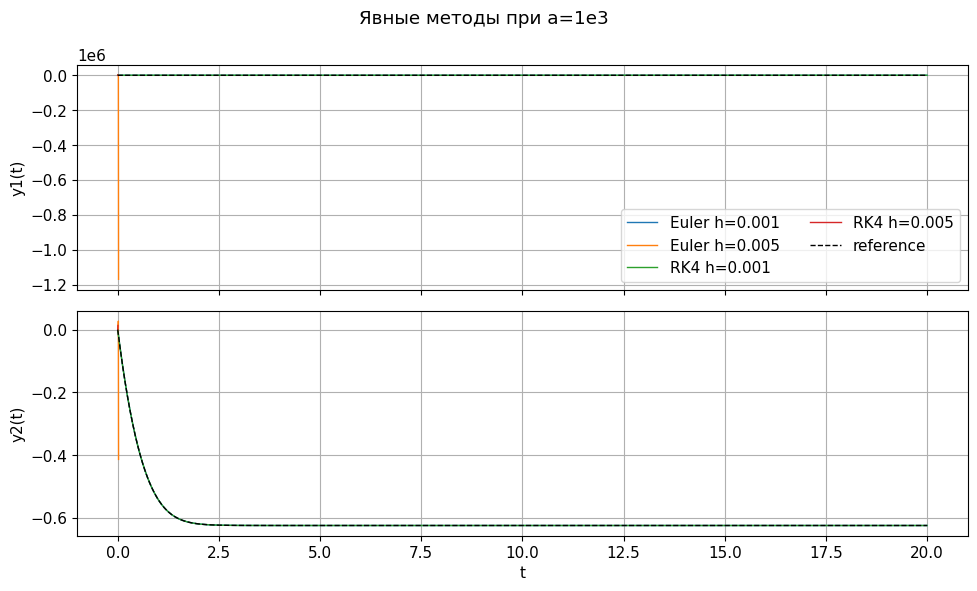

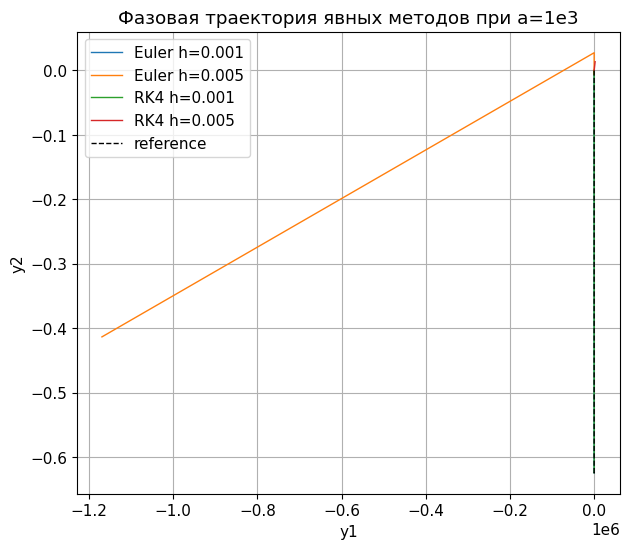

In [5]:
def plot_components(results, title, ref=None):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for label, (t, y) in results.items():
        tt, yy = finite_prefix(t, y)
        axes[0].plot(tt, yy[:, 0], lw=1.0, label=label)
        axes[1].plot(tt, yy[:, 1], lw=1.0, label=label)
    if ref is not None:
        grid = np.linspace(T0, T_END, 2000)
        yy = ref.sol(grid).T
        axes[0].plot(grid, yy[:, 0], "k--", lw=1.0, label="reference")
        axes[1].plot(grid, yy[:, 1], "k--", lw=1.0, label="reference")
    axes[0].set_ylabel("y1(t)")
    axes[1].set_ylabel("y2(t)")
    axes[1].set_xlabel("t")
    axes[0].legend(ncol=2)
    fig.suptitle(title)
    fig.tight_layout()


def plot_phase(results, title, ref=None):
    plt.figure(figsize=(7, 6))
    for label, (t, y) in results.items():
        tt, yy = finite_prefix(t, y)
        plt.plot(yy[:, 0], yy[:, 1], lw=1.0, label=label)
    if ref is not None:
        grid = np.linspace(T0, T_END, 2000)
        yy = ref.sol(grid).T
        plt.plot(yy[:, 0], yy[:, 1], "k--", lw=1.0, label="reference")
    plt.xlabel("y1")
    plt.ylabel("y2")
    plt.title(title)
    plt.legend()


explicit_results = {
    "Euler h=0.001": explicit_euler(1e3, 0.001),
    "Euler h=0.005": explicit_euler(1e3, 0.005),
    "RK4 h=0.001": rk4_explicit(1e3, 0.001),
    "RK4 h=0.005": rk4_explicit(1e3, 0.005),
}
plot_components(explicit_results, "Явные методы при a=1e3", refs[1e3])
plot_phase(explicit_results, "Фазовая траектория явных методов при a=1e3", refs[1e3])

In [6]:
lambda_fast_1e3 = 3 * 1e3
lambda_fast_1e6 = 3 * 1e6
rows = [
    {"a": "1e3", "Euler stable h estimate": 2 / lambda_fast_1e3, "RK4 stable h estimate": 2.8 / lambda_fast_1e3, "steps to T=20 for Euler estimate": math.ceil(20 / (2 / lambda_fast_1e3))},
    {"a": "1e6", "Euler stable h estimate": 2 / lambda_fast_1e6, "RK4 stable h estimate": 2.8 / lambda_fast_1e6, "steps to T=20 for Euler estimate": math.ceil(20 / (2 / lambda_fast_1e6))},
]
pd.DataFrame(rows)

,a,Euler stable h estimate,RK4 stable h estimate,steps to T=20 for Euler estimate
0,1e3,6.666667e-04,9.333333e-04,30000
1,1e6,6.666667e-07,9.333333e-07,30000000


## Неявные методы: графики и результаты

Для жестких методов берем существенно более крупные шаги, чем допускают явные схемы. Сравнение проводится для $a=10^3$ и $a=10^6$.

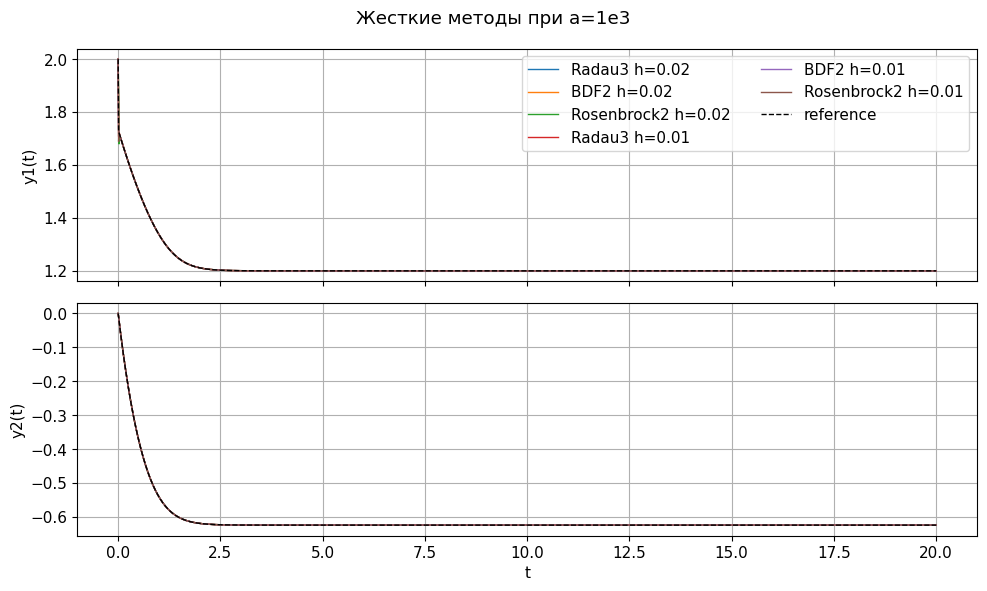

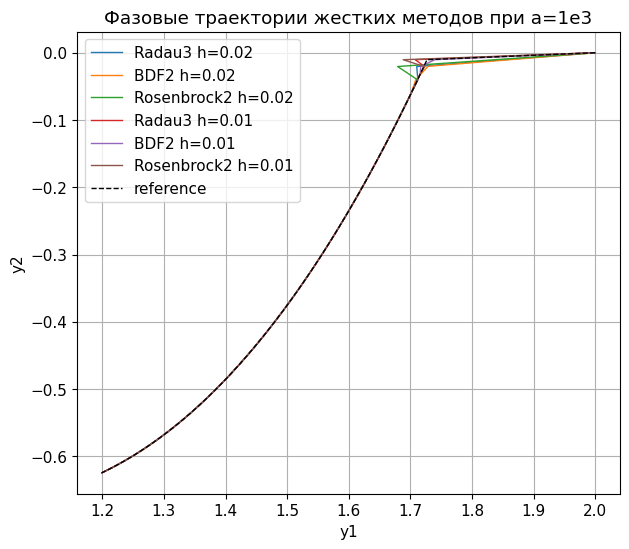

In [7]:
implicit_results_1e3 = {}
for h in [0.02, 0.01]:
    t, y, it = radau_iia3(1e3, h)
    implicit_results_1e3[f"Radau3 h={h:g}"] = (t, y)
    t, y, it = gear_bdf2(1e3, h)
    implicit_results_1e3[f"BDF2 h={h:g}"] = (t, y)
    t, y = rosenbrock2(1e3, h)
    implicit_results_1e3[f"Rosenbrock2 h={h:g}"] = (t, y)

plot_components(implicit_results_1e3, "Жесткие методы при a=1e3", refs[1e3])
plot_phase(implicit_results_1e3, "Фазовые траектории жестких методов при a=1e3", refs[1e3])

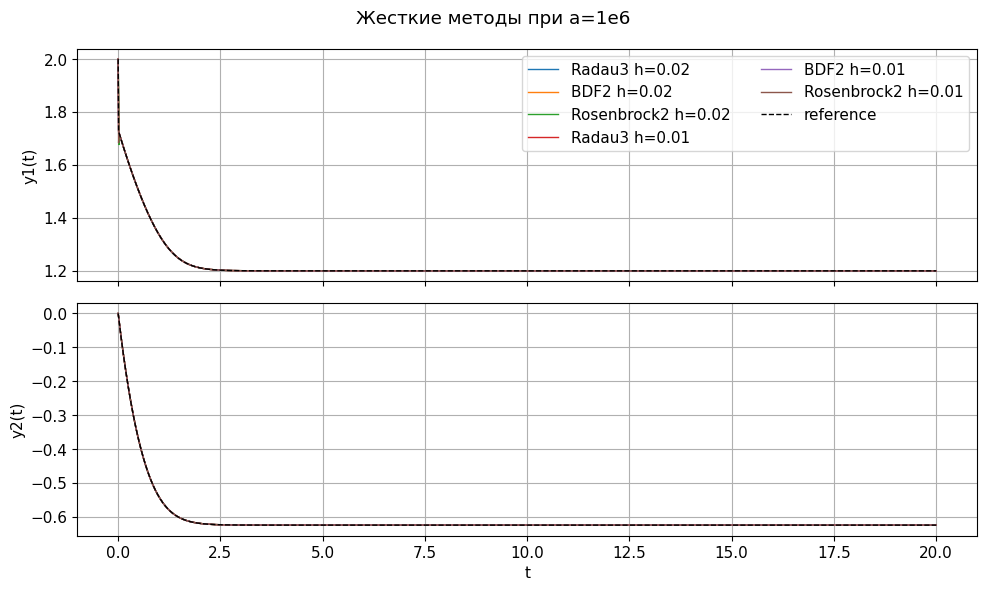

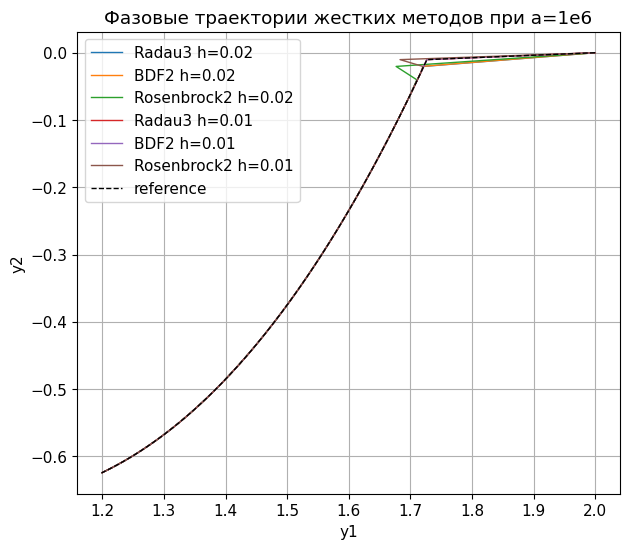

In [8]:
implicit_results_1e6 = {}
for h in [0.02, 0.01]:
    t, y, it = radau_iia3(1e6, h)
    implicit_results_1e6[f"Radau3 h={h:g}"] = (t, y)
    t, y, it = gear_bdf2(1e6, h)
    implicit_results_1e6[f"BDF2 h={h:g}"] = (t, y)
    t, y = rosenbrock2(1e6, h)
    implicit_results_1e6[f"Rosenbrock2 h={h:g}"] = (t, y)

plot_components(implicit_results_1e6, "Жесткие методы при a=1e6", refs[1e6])
plot_phase(implicit_results_1e6, "Фазовые траектории жестких методов при a=1e6", refs[1e6])

## Таблицы ошибок

Ошибки считаются относительно референсного решения `Radau`. В релаксационных задачах максимум ошибки может быть большим около быстрых переходов, потому что небольшая фазовая ошибка сдвигает момент скачка. Поэтому дополнительно полезно смотреть не только на таблицы, но и на фазовые портреты.

In [9]:
def max_error(ref, t, y):
    tt, yy = finite_prefix(t, y)
    ref_y = ref.sol(tt).T
    return float(np.max(np.linalg.norm(yy - ref_y, axis=1)))


def final_error(ref, t, y):
    tt, yy = finite_prefix(t, y)
    ref_y = ref.sol(tt[-1]).reshape(2)
    return float(np.linalg.norm(yy[-1] - ref_y))


def summary_table(a, results):
    rows = []
    for name, (t, y) in results.items():
        tt, yy = finite_prefix(t, y)
        rows.append({
            "method": name,
            "finite_to": tt[-1] if len(tt) else np.nan,
            "max_error": max_error(refs[a], t, y) if len(tt) else np.nan,
            "final_error": final_error(refs[a], t, y) if len(tt) else np.nan,
            "max_abs_y": np.nanmax(np.abs(yy)) if len(tt) else np.nan,
        })
    return pd.DataFrame(rows)


summary_1e3 = summary_table(1e3, {**explicit_results, **implicit_results_1e3})
summary_1e6 = summary_table(1e6, implicit_results_1e6)

summary_1e3

,method,finite_to,max_error,final_error,max_abs_y
0,Euler h=0.001,20.000,4.284674e-01,3.275835e-14,2.000000e+00
1,Euler h=0.005,0.020,1.169649e+06,1.169649e+06,1.169647e+06
2,RK4 h=0.001,20.000,1.088847e-02,3.271373e-14,2.000000e+00
3,RK4 h=0.005,0.005,2.330232e+03,2.330232e+03,2.331962e+03
4,Radau3 h=0.02,20.000,1.153117e-02,4.883285e-11,2.000000e+00
5,BDF2 h=0.02,20.000,6.732517e-03,3.724135e-12,2.000000e+00
6,Rosenbrock2 h=0.02,20.000,4.253684e-02,7.259874e-15,2.000000e+00
7,Radau3 h=0.01,20.000,1.925571e-02,1.531039e-10,2.000000e+00
8,BDF2 h=0.01,20.000,1.274868e-02,2.622367e-12,2.000000e+00
9,Rosenbrock2 h=0.01,20.000,3.868973e-02,2.730788e-15,2.000000e+00


In [10]:
summary_1e6

,method,finite_to,max_error,final_error,max_abs_y
0,Radau3 h=0.02,20.0,0.000014,2.597295e-12,2.0
1,BDF2 h=0.02,20.0,0.000400,5.795151e-13,2.0
2,Rosenbrock2 h=0.02,20.0,0.044808,3.219570e-14,2.0
3,Radau3 h=0.01,20.0,0.000027,1.436473e-13,2.0
4,BDF2 h=0.01,20.0,0.000105,2.187590e-14,2.0
5,Rosenbrock2 h=0.01,20.0,0.043576,2.773070e-14,2.0


## Особенности решения

1. Явные методы вынуждены брать шаг, ограниченный быстрым собственным направлением. Для $a=10^6$ оценка для явного Эйлера дает примерно $6.7\cdot 10^{-7}$, то есть около $3\cdot 10^7$ шагов до $T=20$.
2. Radau IIA порядка 3 устойчиво проходит быстрые слои, потому что является L-устойчивым неявным RK-методом. Цена шага -- решение системы нелинейных уравнений по стадиям.
3. Rosenbrock2 требует только решения СЛАУ с матрицами $I-hJ$ и поэтому проще на каждом шаге. Для сильно жесткой задачи он хорошо демонстрирует преимущество Rosenbrock-подхода: нелинейная итерация заменяется линеаризацией.
4. BDF2 как метод Гира также хорошо подходит для жестких задач. Он дешевле Radau по числу неизвестных в нелинейной системе на шаге, но требует стартового значения и может сильнее сглаживать быстрые переходы.
5. Для релаксационных колебаний фазовый портрет часто информативнее максимальной поточечной ошибки: малый сдвиг момента скачка может дать большую ошибку по норме, хотя качественная траектория построена правильно.

## Вывод

В работе исследована жесткая система Бонгоффера--Ван-дер-Поля при $a=10^3$ и $a=10^6$. Реализованы явные методы для демонстрации ограничения устойчивости, неявный метод Рунге--Кутты Radau IIA порядка 3, метод Розенброка ROS2 порядка 2 и метод Гира BDF2.

Расчеты показывают, что явные методы становятся неэффективными при росте $a$: допустимый шаг убывает пропорционально $1/a$. Неявные и линейно-неявные методы позволяют считать задачу на существенно более крупных шагах и сохраняют характерную фазовую траекторию релаксационных колебаний. Среди реализованных методов Radau IIA наиболее устойчив к жестким переходам, Rosenbrock2 удобен за счет решения только СЛАУ, а BDF2 является хорошим компромиссом для длительного интегрирования жестких систем.